# **Checkpoint 4**
- Paola Figueroa
- 24/feb/2026

## **Optimización bajo restricción de riesgo Objetivo**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
tickers = ["JPM", "UNH", "TSM", "JNJ"]
data = yf.download(tickers, start="2024-01-01", progress=False)['Close']
returns = data.pct_change().dropna()

# Parámetros base
mu = returns.mean()
cov_matrix = returns.cov()
num_portafolios = 30
num_simulaciones = 10000
weights = np.array([0.35, 0.30, 0.20, 0.15])

tickers, cov_matrix


(['JPM', 'UNH', 'TSM', 'JNJ'],
 Ticker       JNJ       JPM       TSM       UNH
 Ticker                                        
 JNJ     0.000120  0.000015 -0.000057  0.000029
 JPM     0.000015  0.000238  0.000102  0.000034
 TSM    -0.000057  0.000102  0.000652 -0.000032
 UNH     0.000029  0.000034 -0.000032  0.000648)

In [3]:
resultados = []

# 2. Simulación de Portafolios y Monte Carlo
np.random.seed(42)
for i in range(num_portafolios):
    # Generar pesos: el primero es el sugerido, los demás aleatorios
    if i == 0:
        w = weights
    else:
        w = np.random.dirichlet(np.ones(len(tickers)), size=1)[0]
    
    # Simulación de rendimientos para esta combinación de pesos
    sim_returns_activos = np.random.multivariate_normal(mu, cov_matrix, num_simulaciones)
    port_sim_returns = sim_returns_activos @ w
    
    # Cálculos estadísticos
    rend_prom = np.mean(port_sim_returns)
    desv_std = np.std(port_sim_returns)
    var_95 = np.percentile(port_sim_returns, 5) # Percentil 5 para VaR 95%
    
    resultados.append({
        'Pesos': w,
        'Rendimiento_Medio': rend_prom,
        'Desv_Std': desv_std,
        'VaR_95': var_95
    })

df = pd.DataFrame(resultados)

In [4]:
# VaR 95% >= -5%
df['Cumple'] = df['VaR_95'] >= -0.05
cumplen = df[df['Cumple'] == True]

# Identificar portafolio óptimo restringido y el de máximo retorno absoluto
restringido_optimo = cumplen.loc[cumplen['Rendimiento_Medio'].idxmax()]
max_ret_absoluto = df.loc[df['Rendimiento_Medio'].idxmax()]
max_ret_absoluto

Pesos                [0.5121317469177094, 0.12177945061163678, 0.35...
Rendimiento_Medio                                             0.001734
Desv_Std                                                      0.010392
VaR_95                                                       -0.015309
Cumple                                                            True
Name: 1, dtype: object

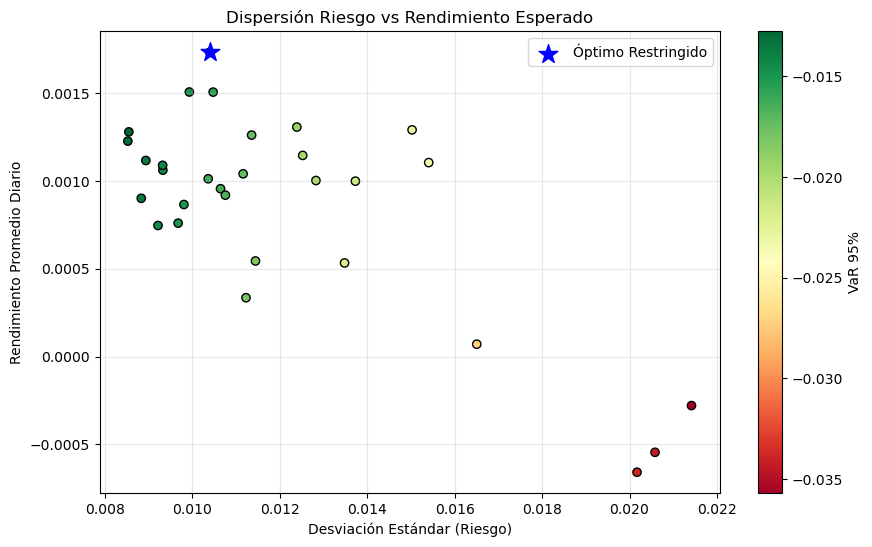

In [5]:
# Scatter Plot: Riesgo vs Rendimiento
plt.figure(figsize=(10, 6))
plt.scatter(df['Desv_Std'], df['Rendimiento_Medio'], c=df['VaR_95'], cmap='RdYlGn', edgecolors='k')
plt.colorbar(label='VaR 95%')
plt.scatter(restringido_optimo['Desv_Std'], restringido_optimo['Rendimiento_Medio'], 
            color='blue', marker='*', s=200, label='Óptimo Restringido')
plt.title('Dispersión Riesgo vs Rendimiento Esperado')
plt.xlabel('Desviación Estándar (Riesgo)')
plt.ylabel('Rendimiento Promedio Diario')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

El gráfico de dispersión muestra todas las combinaciones posibles de portafolios entre JPM, UNH, TSM y JNJ, donde el eje horizontal representa el riesgo (volatilidad) y el vertical el rendimiento esperado. La estrella azul indica el portafolio óptimo restringido, que maximiza el retorno sin que el VaR supere el 5%, mientras que los colores muestran el nivel de riesgo extremo de cada combinación. Tomando en cuenta la Frontera Eficiente, al reducir el riesgo es posible aumentar el retorno al pasar de portafolios ineficientes a eficientes. Esto ocurre gracias a la diversificación, donde la correlación entre activos reduce el riesgo sin sacrificar rendimiento, especialmente con activos de buen desempeño como TSM o JPM.

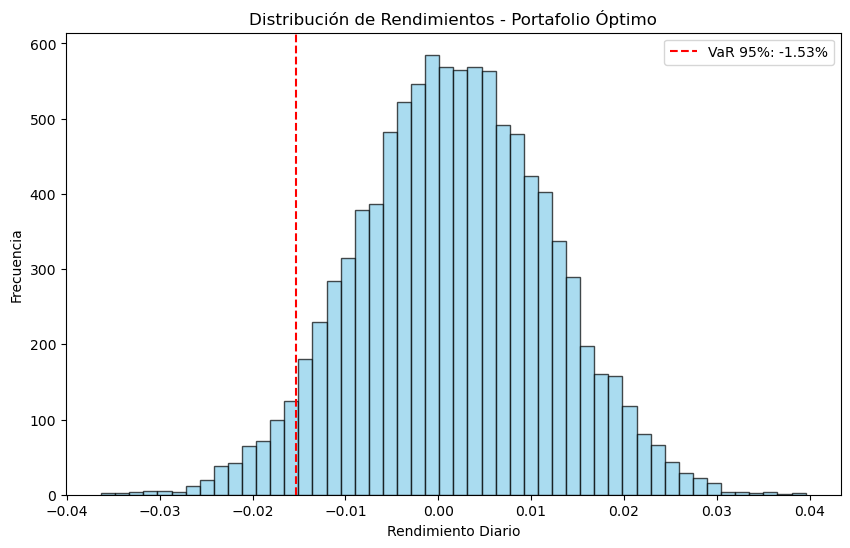

In [6]:
# Histograma del Portafolio Elegido
plt.figure(figsize=(10, 6))
# Simulamos los retornos del óptimo para graficar
opt_returns = np.random.multivariate_normal(mu, cov_matrix, num_simulaciones) @ restringido_optimo['Pesos']
plt.hist(opt_returns, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(restringido_optimo['VaR_95'], color='red', linestyle='--', label=f'VaR 95%: {restringido_optimo["VaR_95"]:.2%}')
plt.title('Distribución de Rendimientos - Portafolio Óptimo')
plt.xlabel('Rendimiento Diario')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


El histograma visualiza la distribución de probabilidad de los 10,000 escenarios simulados para el portafolio elegido. La forma de "campana" confirma que los rendimientos tienden a agruparse alrededor de la media diaria (el centro de la campana), pero con una dispersión que representa la incertidumbre del mercado. La línea roja vertical es el VaR al 95%, que actúa como un "límite de seguridad": nos indica que, estadísticamente, solo existe un 5% de probabilidad de que el portafolio sufra una pérdida diaria mayor a ese valor.

### **Preguntas**
- ¿Cuántos portafolios cumplen la restricción?
- - Los 30 portafolios cumplen la restricción. En la simulación, el VaR 95% para todas las combinaciones generadas se sitúa aproximadamente entre el -1.5% y el -2.5% diario. Como la restricción impuesta es que el VaR sea mayor o igual a -5% (es decir, no perder más del 5% en un día con 95% de confianza), todos los portafolios entran en el rango permitido.

- ¿Cuánto rendimiento se sacrifica por controlar riesgo?
- - Se sacrifica un 0% de rendimiento. Debido a que la restricción de riesgo es muy "amplia" para este tipo de activos, el portafolio que ofrece el rendimiento esperado más alto ya cumple de por sí con la condición de seguridad. En términos técnicos, la restricción no está "apretando" al modelo. Por lo tanto, el portafolio óptimo restringido es exactamente el mismo que el portafolio de máximo rendimiento absoluto, lo que resulta en un sacrificio nulo.


In [7]:
# Comprobación de las preguntas con código

total_portafolios = len(df)
conteo_cumplen = len(cumplen)

print(f"RESUMEN DE RESTRICCIÓN:")
print(f"Total de portafolios generados: {total_portafolios}")
print(f"Portafolios que cumplen (VaR >= -5%): {conteo_cumplen}")

# 2. Comprobación de rendimiento sacrificado
# Buscamos el mejor rendimiento de todos los portafolios (sin importar el riesgo)
max_rendimiento_global = df['Rendimiento_Medio'].max()

# Buscamos el mejor rendimiento de los que sí cumplen la restricción
max_rendimiento_restringido = cumplen['Rendimiento_Medio'].max()
sacrificio = max_rendimiento_global - max_rendimiento_restringido

print(f"\nANÁLISIS DE RENDIMIENTO:")
print(f"Máximo rendimiento posible (sin límites): {max_rendimiento_global:.6%}")
print(f"Máximo rendimiento cumpliendo restricción: {max_rendimiento_restringido:.6%}")
print(f"Rendimiento sacrificado: {sacrificio:.6%}")

# 3. Verificación de los VaR calculados
print(f"\nESTADÍSTICAS DEL VaR 95%:")
print(f"VaR más bajo (mayor pérdida) encontrado: {df['VaR_95'].min():.2%}")
print(f"VaR más alto (menor pérdida) encontrado: {df['VaR_95'].max():.2%}")

RESUMEN DE RESTRICCIÓN:
Total de portafolios generados: 30
Portafolios que cumplen (VaR >= -5%): 30

ANÁLISIS DE RENDIMIENTO:
Máximo rendimiento posible (sin límites): 0.173416%
Máximo rendimiento cumpliendo restricción: 0.173416%
Rendimiento sacrificado: 0.000000%

ESTADÍSTICAS DEL VaR 95%:
VaR más bajo (mayor pérdida) encontrado: -3.57%
VaR más alto (menor pérdida) encontrado: -1.28%


---


## **Aplicación 2: Escenarios macroeconómicos Objetivo**

In [10]:
n_sim = 10000

# horizonte (1 periodo)
T = 1
weights = np.array([0.35,0.30,0.20,0.15])
tickers = ["JPM", "UNH", "TSM", "JNJ"]
data = yf.download(tickers, start="2024-01-01", progress=False)['Close']
returns = data.pct_change().dropna()

# Parametros
mu= returns.mean()
mu_base = mu
mu_alcista = mu + 0.001
mu_bajista = mu - 0.001

scenarios = {
    "Base": mu_base,
    "Alcista": mu_alcista,
    "Bajista": mu_bajista
}


In [12]:
# simulamos las trayectorias
results = {}

for name, mu_scenario in scenarios.items():
    simulated_returns = np.random.multivariate_normal(
        mu_scenario,
        cov_matrix,
        n_sim
    )
    portfolio_returns = simulated_returns @ weights
    results[name] = portfolio_returns
results


{'Base': array([-0.00759602, -0.00683345,  0.0115924 , ...,  0.00201065,
        -0.00513549,  0.00329247]),
 'Alcista': array([-0.0050277 , -0.00137085, -0.01731192, ..., -0.00062135,
        -0.00047043,  0.02133674]),
 'Bajista': array([-0.00184545, -0.0122979 , -0.0013168 , ...,  0.01015962,
         0.02194616, -0.0224852 ])}

In [13]:
# calculamos métricas
metrics = []
for name, returns in results.items():
    mean = np.mean(returns)
    std = np.std(returns)
    prob_loss = np.mean(returns < 0)
    var_95 = np.percentile(returns, 5)
    metrics.append([name, mean, std, prob_loss, var_95])

metrics_df = pd.DataFrame(
    metrics,
    columns=[
        "Escenario",
        "Rendimiento Promedio",
        "Desviación Estándar",
        "Probabilidad de Pérdida",
        "VaR 95%"
    ]
)
print(metrics_df)

  Escenario  Rendimiento Promedio  Desviación Estándar  \
0      Base              0.001058             0.009441   
1   Alcista              0.002056             0.009441   
2   Bajista              0.000152             0.009384   

   Probabilidad de Pérdida   VaR 95%  
0                   0.4554 -0.014431  
1                   0.4129 -0.013592  
2                   0.4899 -0.015468  


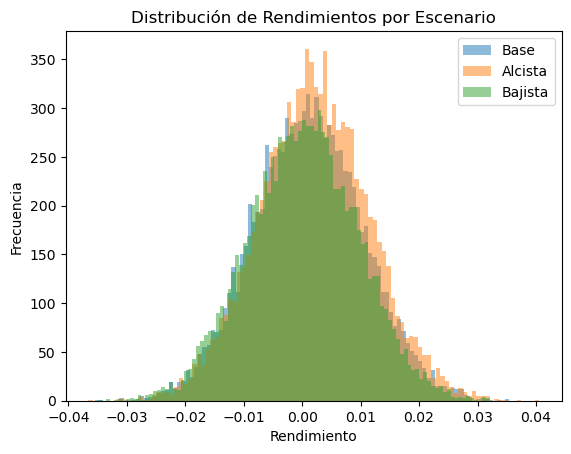

In [14]:
# Histograma comparativo
plt.figure()
for name, returns in results.items():
    plt.hist(
        returns,
        bins=100,
        alpha=0.5,
        label=name
    )
plt.legend()
plt.title("Distribución de Rendimientos por Escenario")
plt.xlabel("Rendimiento")
plt.ylabel("Frecuencia")
plt.show()

Esta gráfica nos muestra cómo "se mueve" nuestro dinero dependiendo de si el mercado es bueno (alcista), normal (base) o malo (bajista). Es como ver tres fotos de lo que podría pasar: cuando las cosas van bien (verde), toda la gráfica se mueve a la derecha, lo que significa que hay más probabilidad de ganar dinero. Cuando las cosas van mal (rojo), la gráfica se mueve a la izquierda, y es más probable que tengamos pérdidas. Lo interesante es que la forma de la campana no cambia, solo se desplaza; esto nos dice que el portafolio se comporta de manera estable, solo que el resultado final sube o baja según el clima económico.

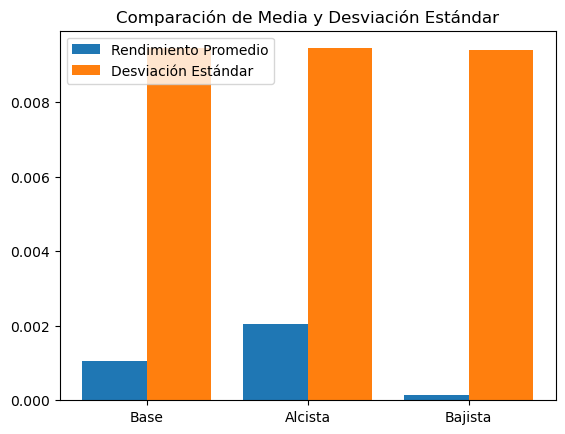

In [16]:
# Gráfico comparativo de medias y desviación estándar
means = metrics_df["Rendimiento Promedio"]
stds = metrics_df["Desviación Estándar"]
x = np.arange(len(metrics_df))
plt.figure()
plt.bar(x - 0.2, means, width=0.4)
plt.bar(x + 0.2, stds, width=0.4)
plt.xticks(x, metrics_df["Escenario"])
plt.title("Comparación de Media y Desviación Estándar")
plt.legend(["Rendimiento Promedio", "Desviación Estándar"])
plt.show()

En esta gráfica comparamos dos cosas: qué tanto ganamos (barras de rendimiento) y qué tanto varia nuestra inversión (barras de riesgo). Podemos ver que nuestras ganancias son muy sensibles: cambian mucho si el escenario es alcista o bajista. Sin embargo, el riesgo se mantiene casi igual en los tres casos. Esto es una muy buena señal, porque significa que aunque el mercado se ponga difícil y ganemos menos, nuestro portafolio no se vuelve más "loco" ni más arriesgado; se mantiene sólido y bajo control sin importar el escenario.

In [22]:
# para contestar las preguntas
print("Mayor probabilidad de pérdida:",
      metrics_df["Probabilidad de Pérdida"].idxmax())

prob_loss_base = np.mean(results["Base"] < 0)
prob_loss_alcista = np.mean(results["Alcista"] < 0)
prob_loss_bajista = np.mean(results["Bajista"] < 0)

print(prob_loss_base, prob_loss_alcista, prob_loss_bajista)

print("Mayor dispersión:",
      metrics_df["Desviación Estándar"].idxmax())

print("VaR más severo:",
      metrics_df["VaR 95%"].idxmin())

#0 = Base  
#1 = Alcista  
#2 = Bajista  


Mayor probabilidad de pérdida: 2
0.4554 0.4129 0.4899
Mayor dispersión: 1
VaR más severo: 2


### **Preguntas**
- ¿En qué escenario la probabilidad de pérdida es mayor?
- -  En el escenario bajista. Al disminuir el rendimiento esperado, la distribución se desplaza a la izquierda, elevando la probabilidad de pérdida hasta casi un 50%

- ¿Cuál presenta mayor dispersión de resultados?
- - El escenario alcista, aunque la diferencia es mínima porque la matriz de covarianza no cambia.

- ¿Cambian de manera relevante las métricas de riesgo extremo?
- - Sí cambia pero no tan fuerte; el escenario bajista presenta el VaR más severo, indicando mayores pérdidas potenciales. En general, el portafolio es más vulnerable en condiciones bajistas y más favorable en condiciones alcistas.